## Goal and how to run

Download the complete `.ipynb`. In VibeIt Studio's file browser use **+ → Import from Files**, then open it. Run code cells from top to bottom. Saved charts show actual executed results; rerunning recomputes them from embedded data.

This lesson assumes basic Python knowledge. Read each method and caption before changing parameters. AI exercises are optional; no AI account is needed for the core workflow. Data lives in notebook metadata, so there is no companion data download. Keep the notebook saved in the active working folder.

Your goal is to understand the research question, execute transparent calculations, check the results, and state the limits of the conclusion.

## Setup and parameters

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='ch06-calibration'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### Load the embedded snapshot

The loader locates this notebook in the working folder by recipe ID and SHA-256, then decompresses and verifies the data. Renaming the file does not change its identity. If loading fails, check the working folder and saved file. Metadata travels with `.ipynb` save/export; copying code to a standalone `.py` does not copy the dataset.

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'models': '48fd2e6e706650fe2ee0c0ad80b6d794a546a1dec78dd9d370ac09db3cc3adbf'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['models']


### Read the method functions

The full implementations appear below. They use the listed bundled packages and standard library; no cookbook helper module is imported at runtime. Inspect input requirements and return values. If you change an algorithm, its checks must still pass.

In [3]:
def linear_calibration(concentration,absorbance):
    """OLS with an intercept; concentrations must state their units in the calling cell."""
    x=np.asarray(concentration,dtype=float);y=np.asarray(absorbance,dtype=float)
    if x.ndim!=1 or x.shape!=y.shape or len(x)<3 or not np.isfinite(x+y).all() or np.ptp(x)==0:
        raise ValueError('Need finite, varying calibration concentrations and >2 observations')
    design=np.column_stack([np.ones(len(x)),x]);coefficient=np.linalg.lstsq(design,y,rcond=None)[0]
    residual=y-design@coefficient;variance=float(residual@residual/(len(x)-2))
    covariance=variance*np.linalg.inv(design.T@design)
    return dict(coefficients=coefficient,residual=residual,variance=variance,covariance=covariance,fitted=design@coefficient)

print("Method ready: linear_calibration")


Method ready: linear_calibration


### Data and model boundary

PubChem properties and conformers are calculated database fields, not new experimental measurements. V2000 parsing here is intentionally limited to atoms, reported bonds and formal charges. Titration and calibration use stated ideal/simulated teaching assumptions. Water pressure uses the attributed IAPWS reference correlation. Descriptors, distances and visual proximity do not establish biological activity or binding strength.

## Steps

### 1. Generate explicitly simulated calibration observations

The model is A=blank+epsilon·l·c plus declared Gaussian noise. There are three simulated replicates at each of nine concentration levels. These are a method benchmark, not laboratory data. Concentration is displayed in micromol/L; absorbance is dimensionless.

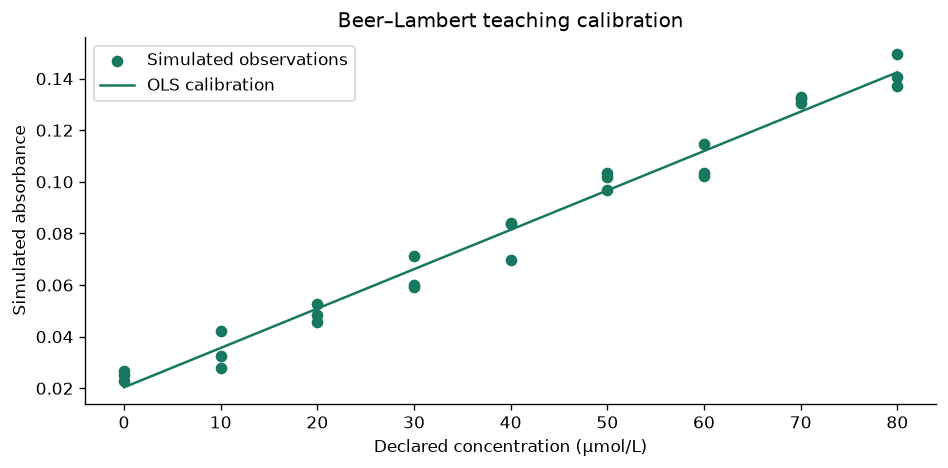

In [4]:
models=snapshot("models");p=models["calibration"];rng=np.random.default_rng(models["seed"])
concentration=np.repeat(np.linspace(0,80,9),3)
truth=p["blank_absorbance"]+p["absorptivity_L_per_mol_cm"]*p["path_length_cm"]*concentration*1e-6
absorbance=truth+rng.normal(0,p["noise_sd_absorbance"],len(truth))
fitted=linear_calibration(concentration,absorbance);intercept,slope=fitted["coefficients"]
fig,ax=plt.subplots(figsize=(8,4));ax.scatter(concentration,absorbance,label="Simulated observations")
grid=np.linspace(0,80,101);ax.plot(grid,intercept+slope*grid,label="OLS calibration")
ax.set(xlabel="Declared concentration (µmol/L)",ylabel="Simulated absorbance",title="Beer–Lambert teaching calibration");ax.legend();plt.tight_layout();plt.show()


### 2. Inspect residuals before inversion

Residuals are observed minus fitted absorbance. The declared noise model is constant-variance Gaussian noise; the plot can reveal deviations if you change the simulation. Residual SD is not automatically a traceable instrument uncertainty.

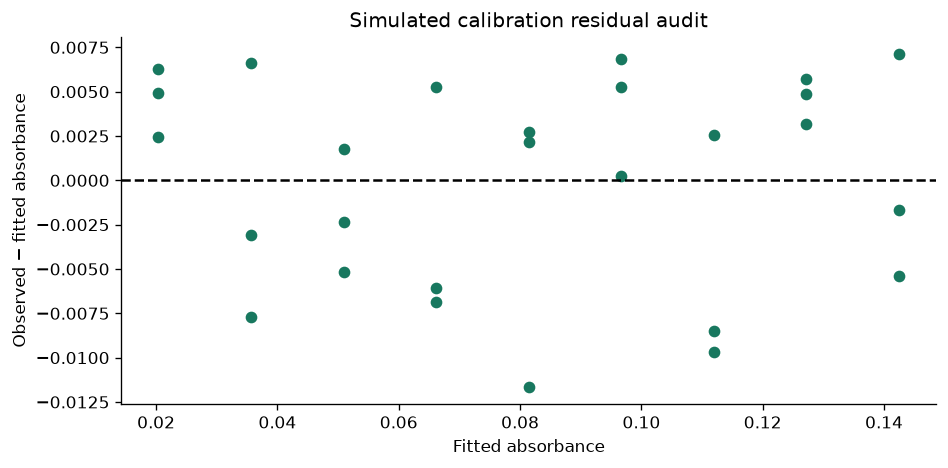

Fitted absorptivity (L/mol/cm): 1526.046117109752 ; fitted blank: 0.020375277723509527


In [5]:
fig,ax=plt.subplots(figsize=(8,4));ax.scatter(fitted["fitted"],fitted["residual"])
ax.axhline(0,color="black",linestyle="--");ax.set(xlabel="Fitted absorbance",ylabel="Observed − fitted absorbance",title="Simulated calibration residual audit");plt.tight_layout();plt.show()
print("Fitted absorptivity (L/mol/cm):",slope*1e6/p["path_length_cm"],"; fitted blank:",intercept)


### 3. Propagate calibration and unknown-measurement variation

Simulate three unknown absorbance replicates. Draw the calibration coefficients from their estimated covariance and unknown mean from its conditional Gaussian model. This produces a model-based interval, conditional on the calibration and noise assumptions, not a universal assay guarantee.

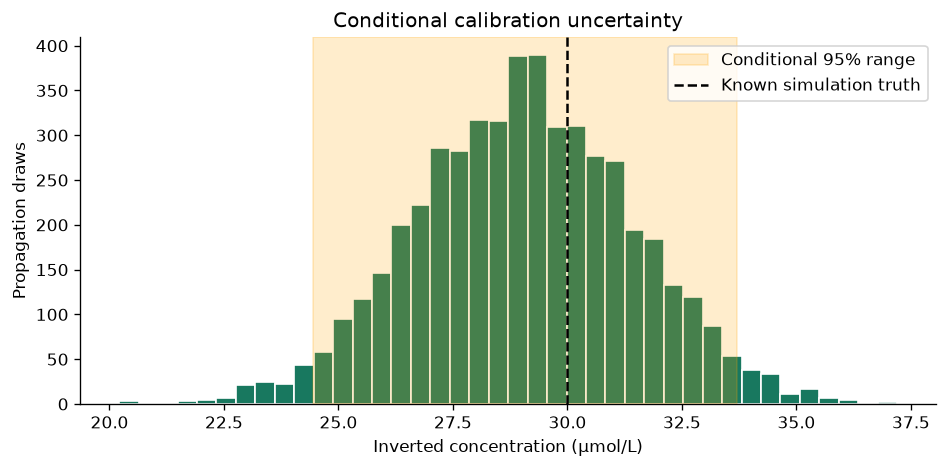

Unknown estimate (µmol/L): 29.025732555623645 ; conditional interval: [24.44653939 33.6977996 ] ; rejected nonpositive slopes: 0


In [6]:
unknown_truth=p["unknown_concentration_mol_per_L"]*1e6
unknown_replicates=p["blank_absorbance"]+p["absorptivity_L_per_mol_cm"]*p["path_length_cm"]*unknown_truth*1e-6+rng.normal(0,p["noise_sd_absorbance"],3)
unknown_mean=float(unknown_replicates.mean());point=(unknown_mean-intercept)/slope
coefficient_draws=rng.multivariate_normal(fitted["coefficients"],fitted["covariance"],size=5000)
measurement_draws=rng.normal(unknown_mean,np.sqrt(fitted["variance"]/3),5000)
valid=coefficient_draws[:,1]>0
concentration_draws=(measurement_draws[valid]-coefficient_draws[valid,0])/coefficient_draws[valid,1]
interval=np.quantile(concentration_draws,[.025,.975])
fig,ax=plt.subplots(figsize=(8,4));ax.hist(concentration_draws,bins=40,edgecolor="white")
ax.axvspan(*interval,color="orange",alpha=.2,label="Conditional 95% range");ax.axvline(unknown_truth,color="black",linestyle="--",label="Known simulation truth")
ax.set(xlabel="Inverted concentration (µmol/L)",ylabel="Propagation draws",title="Conditional calibration uncertainty");ax.legend();plt.tight_layout();plt.show()
print("Unknown estimate (µmol/L):",point,"; conditional interval:",interval,"; rejected nonpositive slopes:",int((~valid).sum()))


### 4. Reconcile the fit and export all assumptions

Check residual orthogonality and agreement of the slope with a direct centred formula. Do not silently clip negative concentration draws or force the interval to contain the known simulated truth. Save the seed, noise, units and full coefficient covariance.

In [7]:
direct_slope=np.sum((concentration-concentration.mean())*(absorbance-absorbance.mean()))/np.sum((concentration-concentration.mean())**2)
assert np.isclose(slope,direct_slope)
assert np.linalg.norm(np.column_stack([np.ones(len(concentration)),concentration]).T@fitted["residual"])<1e-9
assert np.isfinite(concentration_draws).all() and interval[0]<=interval[1]
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
pd.DataFrame({"concentration_micromol_per_L":concentration,"simulated_absorbance":absorbance,"fitted_absorbance":fitted["fitted"],"residual":fitted["residual"]}).to_csv(OUTPUT_DIR/"simulated-calibration.csv",index=False)
pd.DataFrame({"concentration_draw_micromol_per_L":concentration_draws}).to_csv(OUTPUT_DIR/"conditional-propagation.csv",index=False)
(OUTPUT_DIR/"calibration-model.json").write_text(json.dumps({"seed":models["seed"],"declared_simulation":p,"coefficient_units":["absorbance","absorbance per micromol/L"],"coefficients":fitted["coefficients"].tolist(),"covariance":fitted["covariance"].tolist(),"unknown_point_micromol_per_L":point,"conditional_95_micromol_per_L":interval.tolist()},indent=2))
print("Calibration checks passed; exports:",OUTPUT_DIR)


Calibration checks passed; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/ch06-calibration


## Exercises and reference explanation

1. Why keep an intercept in the calibration?
2. Why is the propagated interval conditional?

**Reference explanation.** The blank/background contributes an intercept. The interval depends on the specified linear/noise model and estimated coefficient covariance; it does not guarantee every real assay.

Keep a copy before changing parameters. Compare old and new figures and record which inputs, calculations and conclusions changed.

## Optional AI coding exercises

Open the current notebook in VibeIt's Coding Agent and ask it to read the relevant cells. The core lesson does not depend on AI access; see the Help Center for provider and account setup.

**Prompt 1**

> Using NumPy/Pandas/Matplotlib, compare two stated noise levels with the same concentration design and independent recorded seeds.

**Prompt 2**

> Using the same packages, export unknown replicates and separate measurement-only from calibration-plus-measurement propagation.

**Human acceptance.** Keep explicit simulated-data labels, concentration/absorbance units, original seeds and the full covariance; do not force coverage of truth.

Review the edited source, then manually run affected cells and subsequent checks. Ask the assistant to explain the purpose, packages and data provenance of its changes, and reconcile that explanation with actual output.

## Optional online extension

The network action below is disabled by default. It reports a database version/source without replacing the core data. To refresh data, save a separate experimental version and record the new URL, database release, retrieval date and SHA-256. New results require rerunning and validation.

In [8]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.brentq.html',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## Sources, snapshots and next steps

- [IAPWS saturation reference release](https://iapws.org/public/documents/6dGkr/Supp-sat.pdf) — IAPWS SR1-86(1992): unrestricted publication allowed in all countries (cover page); retrieved 2026-10-09. SHA-256 `a10d38d73339b0713c86cfac88f9adcba137202167ccdfa1cd58238c438361d7`.
  Reference equations and numerical coefficients transcribed from release pages 2–3; pedagogical model values are not new experiments.

- [Authored numerical teaching model parameters](https://github.com/zhiluo20/vibeit/blob/main/cookbook-src/freeze_subject_data.py) — Original teaching parameters/code MIT; reference equation coefficients attributed to IAPWS SR1-86(1992); retrieved 2026-10-09. SHA-256 `4350c4305a83c772fa295a8be0ef86a247f2bfaae930a081720d3cd0c753abe0`.
  Declared parameters and seed; generated trajectories and calibration observations must be labelled simulated.


**Next steps.** Transfer these methods to your own public or authorized data while retaining input checks, recorded parameters and result validation. Document the new experimental design and method limits; this example does not validate a new experiment. Full data licenses and generation instructions accompany the cookbook.